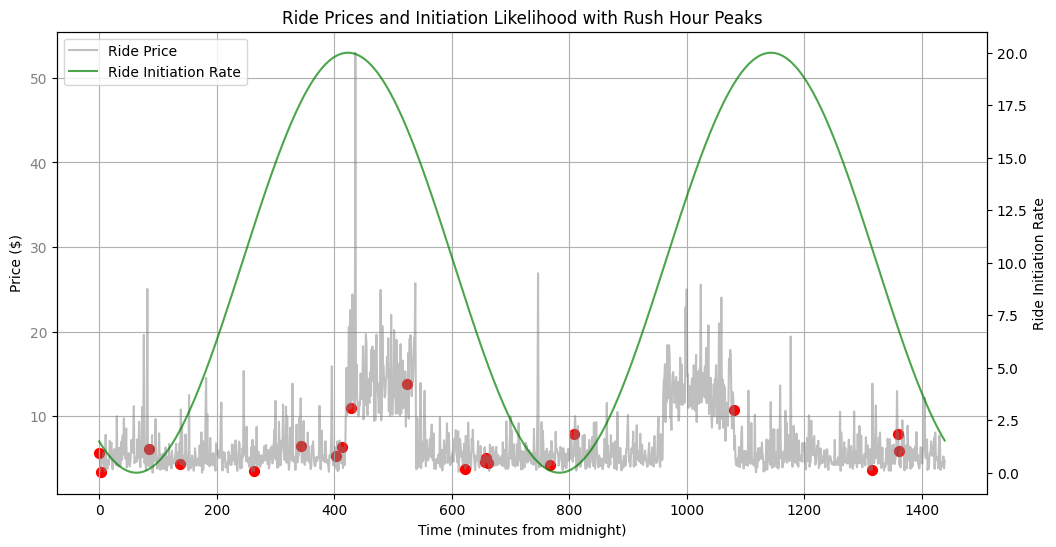

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set the random seed for reproducibility
np.random.seed(42)

# Constants
hours_in_day = 24
minutes_in_hour = 60
total_minutes = hours_in_day * minutes_in_hour
number_of_edges = 100
edge_length = 0.1  # 100 meters
rush_hours_morning = range(7 * 60, 9 * 60)
rush_hours_evening = range(16 * 60, 18 * 60)

# Simulate ride prices
time_minutes = np.arange(0, total_minutes)
prices = []

for minute in time_minutes:
    # Determine if it's rush hour
    if minute in rush_hours_morning or minute in rush_hours_evening:
        congestion_prob = 0.8
    else:
        congestion_prob = 0.2
    
    n = int(np.floor(congestion_prob * number_of_edges))
    m = number_of_edges - n
    # Choose state: congested or non-congested
    speed_cong = np.random.lognormal(size=n, mean=np.log(5), sigma=np.log(5))
    speed_non_cong = np.random.lognormal(size=m, mean=np.log(35), sigma=np.log(2))
    
    # Assuming price is inversely related to speed
    travel_time = edge_length * (np.sum(1 / speed_cong) + np.sum(1 / speed_non_cong))
    price = 2.1 + 2 * travel_time
    prices.append(price)

# Convert to DataFrame for easier handling
prices_df = pd.DataFrame({
    'Time': time_minutes,
    'Price': prices
})

# Ride initiation likelihood (hypothetical Poisson-like behavior with rush hour peaks)
ride_initiation_rate = (
    10 + 10 * np.sin(2 * np.pi * 2* time_minutes / total_minutes + 400)   # Baseline daily pattern
    # 15 * np.isin(time_minutes, rush_hours_morning) +             # Morning rush hour peak
    # 15 * np.isin(time_minutes, rush_hours_evening)               # Evening rush hour peak
)


# Determine the percentage of time the price exceeds a cap K
K = 15  # Hypothetical cap price
exceed_cap = prices_df['Price'] > K
probability_exceeding_K = exceed_cap.sum() / len(exceed_cap)

# Create the combined plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot simulated ride prices
ax1.plot(prices_df['Time'], prices_df['Price'], color='gray', alpha=0.5, label='Ride Price')
ax1.set_xlabel('Time (minutes from midnight)')
ax1.set_ylabel('Price ($)', color='black')
ax1.tick_params('y', labelcolor='gray')
ax1.grid(True)

# Create a second y-axis for ride initiation likelihood
ax2 = ax1.twinx()
ax2.plot(time_minutes, ride_initiation_rate, color='green', alpha=0.7, label='Ride Initiation Rate')
ax2.set_ylabel('Ride Initiation Rate', color='black')
ax2.tick_params('y', labelcolor='black')

# Add title and legend
plt.title('Ride Prices and Initiation Likelihood with Rush Hour Peaks')
fig.legend(loc="upper left", bbox_to_anchor=(0,1), bbox_transform=ax1.transAxes)


# Randomly select indices for red dots
num_red_dots = 20  # Number of red dots to place
random_indices = np.random.choice(prices_df.index, size=num_red_dots, replace=False)
# Plot red dots on selected price points
ax1.scatter(prices_df['Time'].iloc[random_indices], prices_df['Price'].iloc[random_indices], color='red', s=50, label='Random Points')

#Save the figure as a PNG file
plt.savefig('ride_prices_plot.png', format='png', dpi=300)  # Adjust dpi for higher resolution if needed

plt.show()
